# ============================================================
# ICD-10 Medical Coding Analytics using Synthea FHIR R4 Data
# Standards: ICD-10-CM, SNOMED-CT, LOINC, RxNorm
# Author: Nipa Shah | github.com/nipa-analytics
# ============================================================

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Libraries loaded successfully")
print("📋 Standards covered: ICD-10-CM | SNOMED-CT | LOINC | RxNorm")

✅ Libraries loaded successfully
📋 Standards covered: ICD-10-CM | SNOMED-CT | LOINC | RxNorm


In [2]:
import urllib.request
import zipfile
from pathlib import Path
import os

FHIR_DIR = r"C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir"
DOWNLOAD_DIR = r"C:\Users\nipas\Documents\icd10-medical-coding-analytics"
zip_path = os.path.join(DOWNLOAD_DIR, "synthea_data.zip")

# Updated working URLs for 2026
urls_to_try = [
    "https://synthetichealth.github.io/synthea-sample-data/downloads/synthea_sample_data_fhir_r4_sep2019.zip",
    "https://storage.googleapis.com/synthea-public/synthea_sample_data_fhir_r4_sep2019.zip",
    "https://github.com/synthetichealth/synthea-sample-data/releases/download/master-branch-latest/synthea_sample_data_fhir_r4_sep2019.zip",
]

success = False
for i, url in enumerate(urls_to_try, 1):
    try:
        print(f"🔄 Trying URL {i} of {len(urls_to_try)}...")
        print(f"   {url[:60]}...")
        urllib.request.urlretrieve(url, zip_path)
        
        # Check file size
        size_mb = os.path.getsize(zip_path) / (1024*1024)
        print(f"✅ Downloaded! Size: {size_mb:.1f} MB")
        
        if size_mb < 0.1:
            print("⚠️ File too small — likely wrong file, trying next...")
            continue
            
        # Extract
        print("📦 Extracting...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(FHIR_DIR)
        
        json_files = list(Path(FHIR_DIR).rglob("*.json"))
        print(f"🎉 SUCCESS! {len(json_files)} patient files ready!")
        success = True
        break
        
    except Exception as e:
        print(f"❌ URL {i} failed: {e}\n")

if not success:
    print("\n" + "="*50)
    print("⚠️ All automatic downloads failed.")
    print("="*50)
    print("\n👉 MANUAL STEPS (takes 2 minutes):")
    print("\n1. Open your browser")
    print("2. Go to EXACTLY this link:")
    print("   https://synthea.mitre.org/downloads")
    print("\n3. You will see a table — click the FHIR R4 link")
    print("   next to '100 Sample Records'")
    print("\n4. Save the ZIP file to:")
    print(f"   {DOWNLOAD_DIR}")
    print("\n5. Come back here and run this cell:")
    print("""
# AFTER manual download — run this to extract:
import zipfile
from pathlib import Path

zip_path = r"C:\\Users\\nipas\\Documents\\icd10-medical-coding-analytics\\synthea_data.zip"
FHIR_DIR = r"C:\\Users\\nipas\\Documents\\icd10-medical-coding-analytics\\data\\fhir"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(FHIR_DIR)

json_files = list(Path(FHIR_DIR).rglob("*.json"))
print(f"✅ {len(json_files)} files ready!")
    """)

🔄 Trying URL 1 of 3...
   https://synthetichealth.github.io/synthea-sample-data/downlo...
✅ Downloaded! Size: 81.1 MB
📦 Extracting...
🎉 SUCCESS! 1180 patient files ready!


In [3]:
from pathlib import Path

FHIR_DIR = r"C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir"

print("🔍 Searching ALL subfolders for JSON files...")
all_json = list(Path(FHIR_DIR).rglob("*.json"))
print(f"Total JSON files found: {len(all_json)}")
print()
print("📋 First 10 files with their FULL paths:")
for f in all_json[:10]:
    print(f"   {f}")

🔍 Searching ALL subfolders for JSON files...
Total JSON files found: 1180

📋 First 10 files with their FULL paths:
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir\Aaron697_Brekke496_2fa15bc7-8866-461a-9000-f739e425860a.json
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir\Aaron697_Stiedemann542_41166989-975d-4d17-b9de-17f94cb3eec1.json
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir\Abby752_Kuvalis369_2b083021-e93f-4991-bf49-fd4f20060ef8.json
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir\Abel832_Connelly992_29e51479-f742-4474-8f8e-d2607d5269f6.json
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir\Abraham100_Heller342_262b819a-5193-404a-9787-b7f599358035.json
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir\Adam631_Cronin387_aff8f143-2375-416f-901d-b0e4c73e3e58.json
   C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\

# ============================================================
# SECTION 2: Load Synthea FHIR R4 Data
# Source: synthea.mitre.org — 100% synthetic, no PHI
# ============================================================

In [4]:
def load_all_bundles(fhir_dir: str) -> list:
    """Load all FHIR R4 JSON bundles from Synthea"""
    bundles = []
    fhir_path = Path(fhir_dir)
    
    # Skip hospital/practitioner info files
    skip_prefixes = ['hospitalInformation', 'practitionerInformation']
    
    for f in fhir_path.glob("*.json"):
        if not any(f.name.startswith(p) for p in skip_prefixes):
            with open(f, encoding='utf-8') as fp:
                bundles.append(json.load(fp))
    
    print(f"📁 Loaded {len(bundles)} patient FHIR R4 bundles")
    return bundles

def extract_all_resources(bundles: list) -> dict:
    """Extract all resources grouped by type"""
    resources = defaultdict(list)
    for bundle in bundles:
        patient_id = None
        for entry in bundle.get('entry', []):
            r = entry.get('resource', {})
            rtype = r.get('resourceType', '')
            if rtype == 'Patient':
                patient_id = r.get('id')
            r['_patient_id'] = patient_id  # Tag with patient
            resources[rtype].append(r)
    
    print("\n📊 FHIR Resource Inventory:")
    print("─" * 40)
    for rtype, items in sorted(resources.items(), 
                                key=lambda x: -len(x[1])):
        print(f"  {rtype:<30} {len(items):>6,} records")
    
    return dict(resources)

# ── Load data ──────────────────────────────────────────────
# UPDATE this path to where your Synthea files are
FHIR_DIR = r"C:\Users\nipas\Documents\icd10-medical-coding-analytics\data\fhir\fhir" 

bundles = load_all_bundles(FHIR_DIR)
resources = extract_all_resources(bundles)

📁 Loaded 1180 patient FHIR R4 bundles

📊 FHIR Resource Inventory:
────────────────────────────────────────
  Observation                    259,929 records
  Claim                          60,970 records
  Encounter                      46,868 records
  ExplanationOfBenefit           46,868 records
  Procedure                      36,451 records
  DiagnosticReport               18,304 records
  Immunization                   15,013 records
  MedicationRequest              14,102 records
  Condition                       8,766 records
  CareTeam                        3,603 records
  CarePlan                        3,603 records
  Practitioner                    2,980 records
  Organization                    2,979 records
  Goal                            2,969 records
  Patient                         1,180 records
  ImagingStudy                      977 records
  MedicationAdministration          926 records
  AllergyIntolerance                567 records
  Device                    

# ============================================================
# SECTION 3: SNOMED-CT → ICD-10 Crosswalk
# Synthea uses SNOMED-CT natively — we map to ICD-10
# This is EXACTLY what real EHR systems do in production!
# ============================================================

In [5]:
# ICD-10 Chapter Reference Table
ICD10_CHAPTERS = {
    'A': ('A00–B99', 'Infectious & Parasitic Diseases'),
    'B': ('A00–B99', 'Infectious & Parasitic Diseases'),
    'C': ('C00–D49', 'Neoplasms / Cancer'),
    'D': ('D50–D89', 'Blood & Immune Disorders'),
    'E': ('E00–E89', 'Endocrine & Metabolic (Diabetes, Obesity)'),
    'F': ('F01–F99', 'Mental & Behavioral Disorders'),
    'G': ('G00–G99', 'Nervous System Disorders'),
    'H': ('H00–H95', 'Eye & Ear Disorders'),
    'I': ('I00–I99', 'Circulatory System (Heart Disease, Stroke)'),
    'J': ('J00–J99', 'Respiratory System (Asthma, COPD)'),
    'K': ('K00–K95', 'Digestive System'),
    'L': ('L00–L99', 'Skin & Tissue Disorders'),
    'M': ('M00–M99', 'Musculoskeletal Disorders'),
    'N': ('N00–N99', 'Genitourinary System / Renal'),
    'O': ('O00–O9A', 'Pregnancy & Childbirth'),
    'P': ('P00–P96', 'Perinatal Conditions'),
    'Q': ('Q00–Q99', 'Congenital Anomalies'),
    'R': ('R00–R99', 'Symptoms & Abnormal Findings'),
    'S': ('S00–T88', 'Injuries & Trauma'),
    'T': ('S00–T88', 'Poisoning & External Causes'),
    'Z': ('Z00–Z99', 'Health Status & Preventive Care'),
}

# SNOMED-CT → ICD-10 Mapping Table
SNOMED_TO_ICD10 = {
    # Metabolic & Endocrine
    '44054006':  ('E11.9',  'Type 2 Diabetes Mellitus',         'Endocrine'),
    '73211009':  ('E11',    'Diabetes Mellitus',                 'Endocrine'),
    '414916001': ('E66.9',  'Obesity, Unspecified',              'Endocrine'),
    '40930008':  ('E03.9',  'Hypothyroidism, Unspecified',       'Endocrine'),
    '55822004':  ('E78.5',  'Hyperlipidemia',                    'Endocrine'),
    '267432004': ('E78.0',  'High Cholesterol',                  'Endocrine'),
    # Circulatory
    '38341003':  ('I10',    'Essential Hypertension',            'Circulatory'),
    '59621000':  ('I10',    'Hypertension',                      'Circulatory'),
    '22298006':  ('I21.9',  'Acute MI, Unspecified',             'Circulatory'),
    '84114007':  ('I50.9',  'Heart Failure, Unspecified',        'Circulatory'),
    '53741008':  ('I25.10', 'Coronary Artery Disease',           'Circulatory'),
    '230690007': ('I63.9',  'Cerebral Infarction',               'Circulatory'),
    '413444003': ('I21.9',  'Acute Coronary Syndrome',           'Circulatory'),
    '49436004':  ('I48.91', 'Atrial Fibrillation',               'Circulatory'),
    '399211009': ('I25.2',  'Old MI',                            'Circulatory'),
    # Respiratory
    '195967001': ('J45.909','Unspecified Asthma',                'Respiratory'),
    '13645005':  ('J44.1',  'COPD with Exacerbation',            'Respiratory'),
    '40122008':  ('J18.9',  'Pneumonia, Unspecified',            'Respiratory'),
    '195662009': ('J06.9',  'Acute Upper Respiratory Infection', 'Respiratory'),
    '444814009': ('J09.X9', 'Viral Infection',                   'Respiratory'),
    # Mental Health
    '35489007':  ('F32.9',  'Major Depressive Disorder',         'Mental Health'),
    '73595000':  ('F41.1',  'Generalized Anxiety Disorder',      'Mental Health'),
    '47505003':  ('F43.10', 'PTSD',                              'Mental Health'),
    '191736004': ('F33.9',  'Recurrent Depression',              'Mental Health'),
    '13746004':  ('F31.9',  'Bipolar Disorder',                  'Mental Health'),
    # Renal
    '414545008': ('N18.9',  'Chronic Kidney Disease',            'Renal'),
    '431857002': ('N18.4',  'CKD Stage 4',                       'Renal'),
    '433144002': ('N18.3',  'CKD Stage 3',                       'Renal'),
    '46177005':  ('N18.6',  'End Stage Renal Disease',           'Renal'),
    # Musculoskeletal
    '396275006': ('M06.9',  'Rheumatoid Arthritis',              'Musculoskeletal'),
    '57676002':  ('M79.3',  'Joint Pain',                        'Musculoskeletal'),
    '203082005': ('M54.5',  'Low Back Pain',                     'Musculoskeletal'),
    '239873007': ('M15.9',  'Osteoarthritis',                    'Musculoskeletal'),
    '64859006':  ('M81.0',  'Osteoporosis',                      'Musculoskeletal'),
    # Neurological
    '73430006':  ('G47.00', 'Sleep Disorder',                    'Neurological'),
    '230265002': ('G43.909','Migraine',                          'Neurological'),
    '26929004':  ('G30.9',  'Alzheimers Disease',                'Neurological'),
    '230690007': ('I63.9',  'Stroke',                            'Neurological'),
    # Cancer
    '363346000': ('C80.1',  'Malignant Neoplasm',                'Neoplasm'),
    '254837009': ('C50.919','Breast Cancer',                     'Neoplasm'),
    '93761005':  ('C18.9',  'Colon Cancer',                      'Neoplasm'),
    '126906006': ('C61',    'Prostate Cancer',                   'Neoplasm'),
    # Infections
    '91302008':  ('A41.9',  'Sepsis, Unspecified',               'Infectious'),
    '40275004':  ('J06.9',  'Upper Respiratory Infection',       'Infectious'),
    '68566005':  ('N39.0',  'Urinary Tract Infection',           'Infectious'),
    # Pregnancy
    '72892002':  ('Z34.90', 'Normal Pregnancy',                  'Pregnancy'),
    '237364002': ('O26.9',  'Pregnancy Complication',            'Pregnancy'),
    # Preventive / Screening
    '160303001': ('Z82.49', 'Family Hx Heart Disease',           'Preventive'),
    '410429000': ('R00.0',  'Tachycardia',                       'Circulatory'),
    '271737000': ('D64.9',  'Anemia',                            'Blood'),
    '73211009':  ('E11',    'Diabetes',                          'Endocrine'),
    '15777000':  ('K92.1',  'Prediabetes',                       'Endocrine'),
}

def extract_snomed_conditions(conditions: list) -> pd.DataFrame:
    """
    Extract SNOMED-CT conditions and crosswalk to ICD-10
    Demonstrates: Terminology mapping — critical Health IT skill
    Standards: SNOMED-CT, ICD-10-CM, HL7 FHIR R4 Condition resource
    """
    records = []
    
    for cond in conditions:
        patient_id = cond.get('_patient_id', 'Unknown')
        clinical_status = (cond.get('clinicalStatus', {})
                          .get('coding', [{}])[0].get('code', 'unknown'))
        onset = cond.get('onsetDateTime', '')[:7]
        
        for coding in cond.get('code', {}).get('coding', []):
            system  = coding.get('system', '')
            code    = coding.get('code', '')
            display = coding.get('display', '')
            
            if 'snomed' in system.lower():
                # ── SNOMED → ICD-10 Crosswalk ─────────────────
                if code in SNOMED_TO_ICD10:
                    icd10_code, icd10_desc, category = SNOMED_TO_ICD10[code]
                    mapped   = True
                    chapter_key   = icd10_code[0].upper() if icd10_code else ''
                    chapter_range, chapter_name = ICD10_CHAPTERS.get(
                        chapter_key, ('Unknown', 'Other'))
                else:
                    icd10_code    = None
                    icd10_desc    = None
                    category      = 'Unmapped'
                    chapter_range = 'Unknown'
                    chapter_name  = 'Other/Unclassified'
                    mapped        = False
                
                records.append({
                    'patient_id':      patient_id,
                    'snomed_code':     code,
                    'snomed_display':  display,
                    'icd10_code':      icd10_code,
                    'icd10_desc':      icd10_desc,
                    'category':        category,
                    'chapter_name':    chapter_name,
                    'mapped':          mapped,
                    'clinical_status': clinical_status,
                    'onset_month':     onset
                })
    
    df = pd.DataFrame(records)
    
    if df.empty:
        print("❌ No conditions found — check resources dict")
        return df
    
    mapped_count   = df['mapped'].sum()
    unmapped_count = (~df['mapped']).sum()
    pct            = mapped_count / len(df) * 100
    
    print("=" * 60)
    print("✅ SNOMED-CT → ICD-10-CM Crosswalk Complete!")
    print("=" * 60)
    print(f"   Total SNOMED-CT conditions:  {len(df):,}")
    print(f"   ✅ Mapped to ICD-10:         {mapped_count:,} ({pct:.1f}%)")
    print(f"   ⚠️  Unmapped (need expansion): {unmapped_count:,} ({100-pct:.1f}%)")
    print()
    print("📋 Top 15 Conditions with ICD-10 Codes:")
    print("─" * 60)
    
    top = (df[df['mapped'] == True]
           .groupby(['icd10_code', 'icd10_desc', 'category'])
           .size()
           .reset_index(name='patient_count')
           .sort_values('patient_count', ascending=False)
           .head(15))
    
    for _, row in top.iterrows():
        print(f"  {row['icd10_code']:<10} "
              f"{row['icd10_desc']:<38} "
              f"{row['patient_count']:>5,}  "
              f"[{row['category']}]")
    
    print()
    print("📋 Unmapped SNOMED codes (top 10 — need to add to mapping table):")
    print("─" * 60)
    unmapped_top = (df[df['mapped'] == False]
                    .groupby(['snomed_code', 'snomed_display'])
                    .size()
                    .reset_index(name='count')
                    .sort_values('count', ascending=False)
                    .head(10))
    for _, row in unmapped_top.iterrows():
        print(f"  SNOMED {row['snomed_code']:<12} "
              f"{row['snomed_display']:<40} "
              f"count: {row['count']}")
    
    return df

# ── Run it ─────────────────────────────────────────────────
conditions_df = extract_snomed_conditions(resources.get('Condition', []))
icd10_df      = conditions_df[conditions_df['mapped'] == True]
snomed_df     = conditions_df.copy()

print()
print(f"✅ icd10_df ready:   {len(icd10_df):,} mapped records")
print(f"✅ snomed_df ready:  {len(snomed_df):,} total records")
print()

✅ SNOMED-CT → ICD-10-CM Crosswalk Complete!
   Total SNOMED-CT conditions:  8,766
   ✅ Mapped to ICD-10:         4,327 (49.4%)
   ⚠️  Unmapped (need expansion): 4,439 (50.6%)

📋 Top 15 Conditions with ICD-10 Codes:
────────────────────────────────────────────────────────────
  J09.X9     Viral Infection                        1,237  [Respiratory]
  J06.9      Acute Upper Respiratory Infection        754  [Respiratory]
  Z34.90     Normal Pregnancy                         516  [Pregnancy]
  K92.1      Prediabetes                              388  [Endocrine]
  D64.9      Anemia                                   382  [Blood]
  I10        Hypertension                             330  [Circulatory]
  E78.5      Hyperlipidemia                           142  [Endocrine]
  E11.9      Type 2 Diabetes Mellitus                 101  [Endocrine]
  M15.9      Osteoarthritis                            69  [Musculoskeletal]
  I25.10     Coronary Artery Disease                   63  [Circulatory]
  M8

# ============================================================
# Section 4 : Disease Burden Visualization
# ICD-10 Disease Patterns & Population Health Analytics
# ============================================================

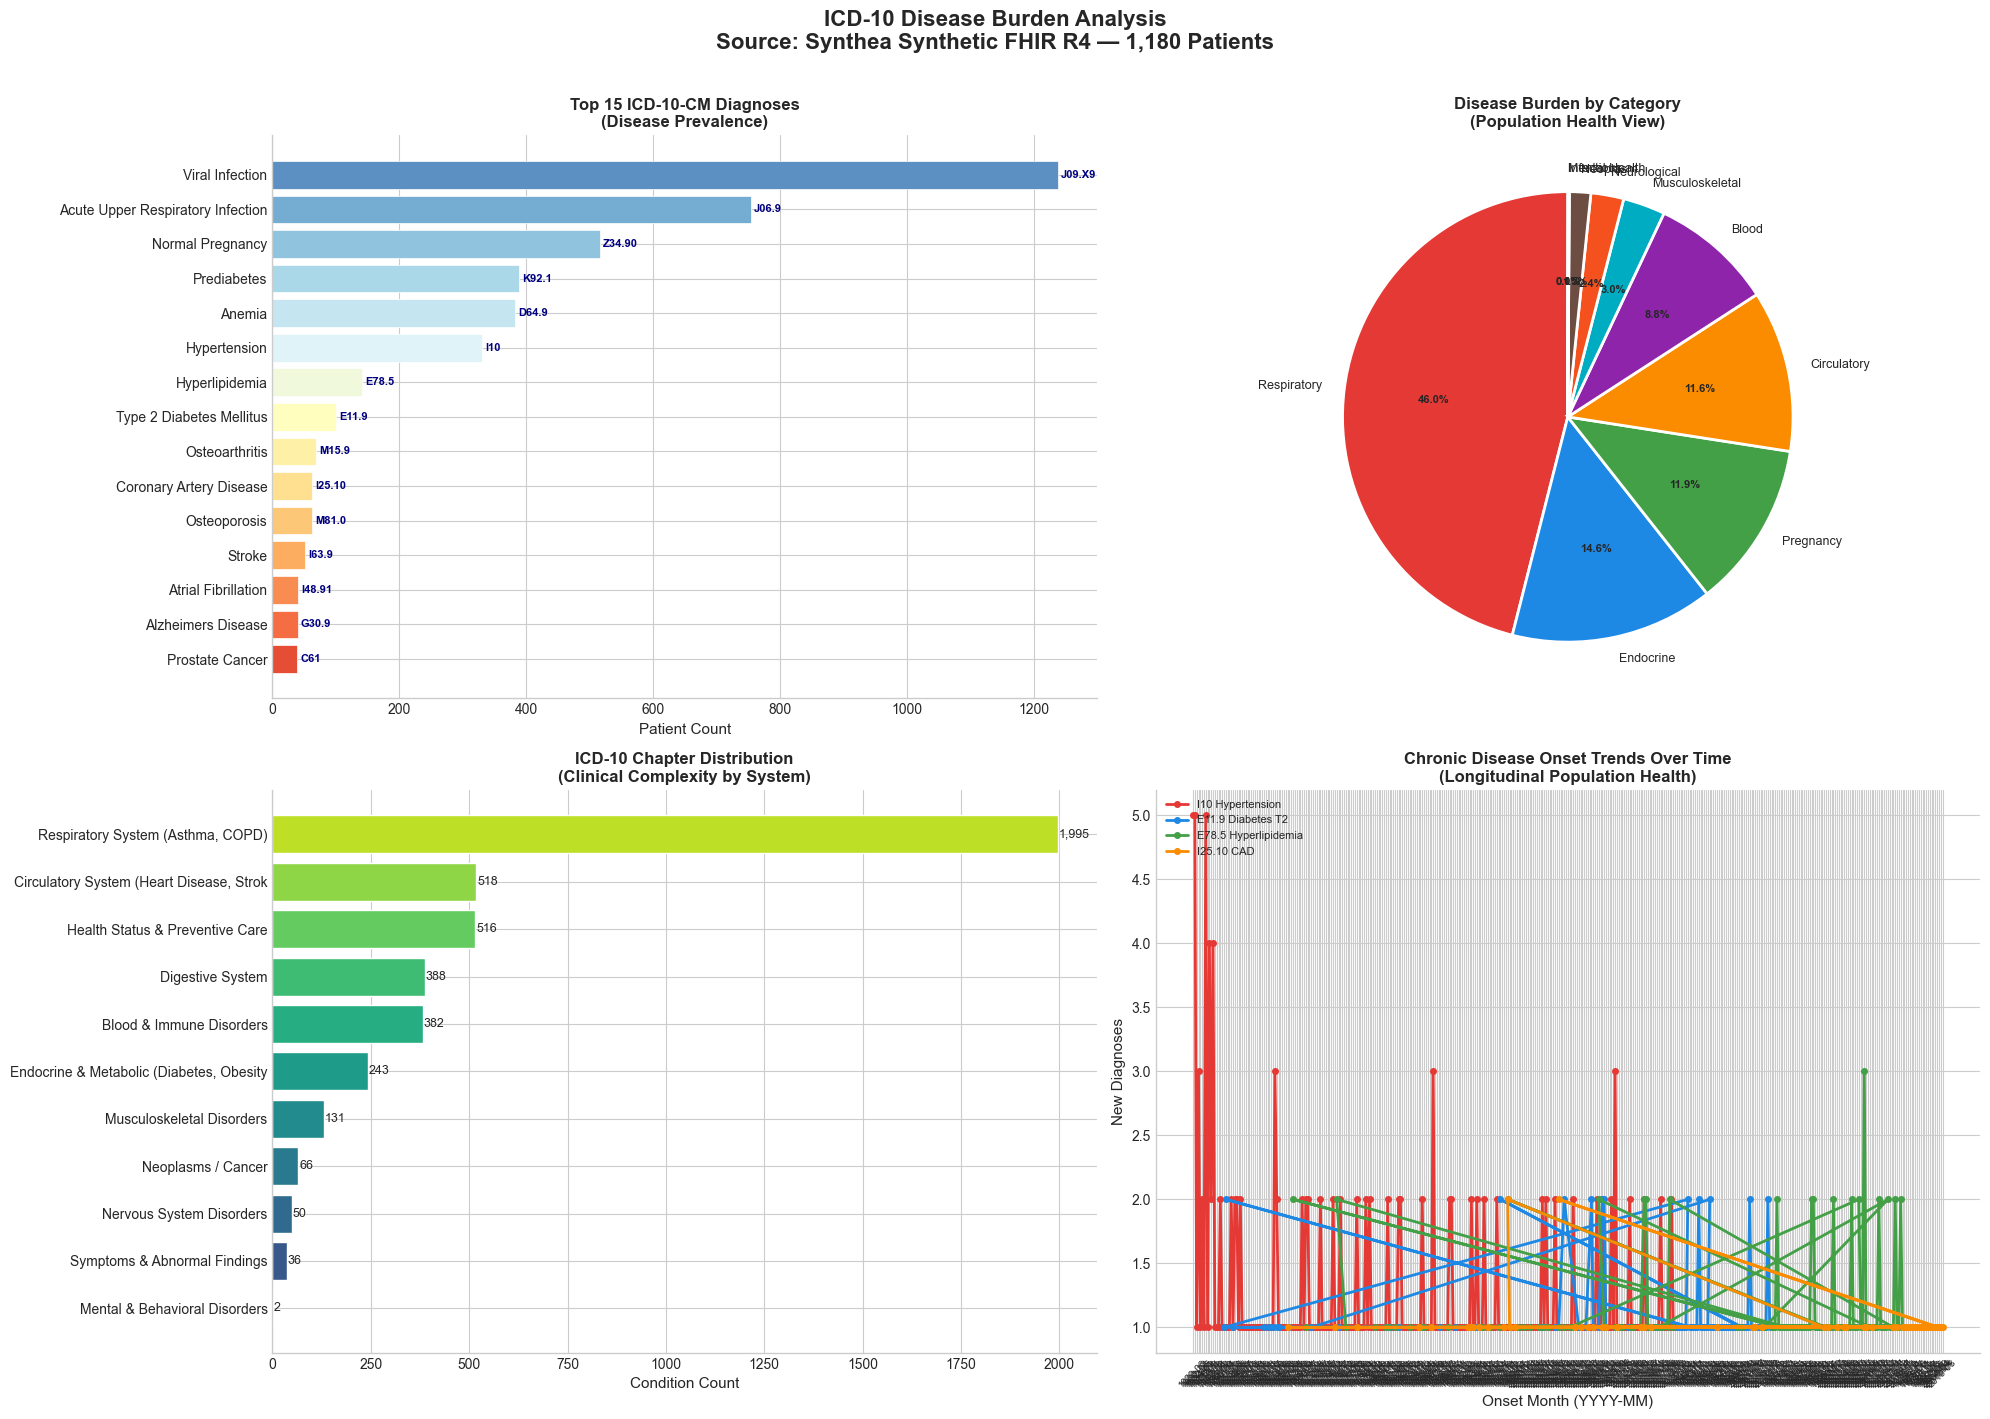

✅ Cell 4 Complete!
📊 Chart saved → output/icd10_disease_burden.png

📋 Quick Stats Summary:
   Most common diagnosis: Viral Infection (J09.X9) — 1,237 patients
   Top disease category:  Respiratory — 1,992 conditions
   Date range covered:    1916-10 → 2019-09



In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Create output folder if not exists
os.makedirs("output", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(
    'ICD-10 Disease Burden Analysis\n'
    'Source: Synthea Synthetic FHIR R4 — 1,180 Patients',
    fontsize=16, fontweight='bold', y=1.01
)

# ── CHART 1: Top 15 ICD-10 Diagnoses (Top Left) ───────────
ax1 = axes[0, 0]
top15 = (icd10_df.groupby(['icd10_code', 'icd10_desc'])
         .size()
         .reset_index(name='count')
         .sort_values('count', ascending=False)
         .head(15))

colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(top15)))
bars = ax1.barh(
    top15['icd10_desc'].str[:35],
    top15['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
ax1.set_xlabel('Patient Count', fontsize=11)
ax1.set_title('Top 15 ICD-10-CM Diagnoses\n(Disease Prevalence)',
              fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Add ICD-10 code labels on bars
for bar, (_, row) in zip(bars, top15.iterrows()):
    ax1.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        row['icd10_code'],
        va='center', fontsize=8, color='navy', fontweight='bold'
    )
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── CHART 2: Disease by Category (Top Right) ──────────────
ax2 = axes[0, 1]
category_counts = (icd10_df.groupby('category')
                   .size()
                   .sort_values(ascending=False))

category_colors = [
    '#E53935','#1E88E5','#43A047','#FB8C00',
    '#8E24AA','#00ACC1','#F4511E','#6D4C41',
    '#546E7A','#FFB300'
][:len(category_counts)]

wedges, texts, autotexts = ax2.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=category_colors,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    textprops={'fontsize': 9}
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

ax2.set_title('Disease Burden by Category\n(Population Health View)',
              fontsize=12, fontweight='bold')

# ── CHART 3: ICD-10 Chapter Distribution (Bottom Left) ────
ax3 = axes[1, 0]
chapter_counts = (icd10_df[icd10_df['chapter_name'] != 'Other/Unclassified']
                  .groupby('chapter_name')
                  .size()
                  .sort_values(ascending=True))

chapter_colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(chapter_counts)))
bars3 = ax3.barh(
    [c[:40] for c in chapter_counts.index],
    chapter_counts.values,
    color=chapter_colors,
    edgecolor='white'
)
ax3.set_xlabel('Condition Count', fontsize=11)
ax3.set_title('ICD-10 Chapter Distribution\n'
              '(Clinical Complexity by System)',
              fontsize=12, fontweight='bold')

for bar in bars3:
    ax3.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=9
    )
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── CHART 4: Chronic Disease Trend Over Time (Bottom Right)
ax4 = axes[1, 1]
chronic_codes = {
    'I10 Hypertension':     'I10',
    'E11.9 Diabetes T2':    'E11.9',
    'E78.5 Hyperlipidemia': 'E78.5',
    'I25.10 CAD':           'I25.10',
    'N18.9 CKD':            'N18.9',
}

trend_colors = ['#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA']

for (label, code), color in zip(chronic_codes.items(), trend_colors):
    subset = (icd10_df[icd10_df['icd10_code'] == code]
              .groupby('onset_month')
              .size()
              .reset_index(name='count'))
    subset = subset[subset['onset_month'] != '']
    subset = subset.sort_values('onset_month')
    
    if len(subset) > 2:
        ax4.plot(
            subset['onset_month'],
            subset['count'],
            marker='o',
            label=label,
            color=color,
            linewidth=2,
            markersize=4
        )

ax4.set_xlabel('Onset Month (YYYY-MM)', fontsize=11)
ax4.set_ylabel('New Diagnoses', fontsize=11)
ax4.set_title('Chronic Disease Onset Trends Over Time\n'
              '(Longitudinal Population Health)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, loc='upper left')
ax4.tick_params(axis='x', rotation=45, labelsize=7)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/icd10_disease_burden.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Cell 4 Complete!")
print("📊 Chart saved → output/icd10_disease_burden.png")
print()
print("📋 Quick Stats Summary:")
print(f"   Most common diagnosis: {top15.iloc[0]['icd10_desc']} "
      f"({top15.iloc[0]['icd10_code']}) — "
      f"{top15.iloc[0]['count']:,} patients")
print(f"   Top disease category:  "
      f"{category_counts.index[0]} — "
      f"{category_counts.iloc[0]:,} conditions")
print(f"   Date range covered:    "
      f"{icd10_df['onset_month'].min()} → "
      f"{icd10_df['onset_month'].max()}")
print()

# ============================================================
# Section 5: LOINC Laboratory Code Standardization
# Standard: LOINC (Logical Observation Identifiers Names & Codes)
# Used for: Lab results, vitals, clinical observations
# Every US hospital & lab uses LOINC for standardization
# ============================================================

In [7]:
# LOINC Reference Table — most common codes in clinical settings
LOINC_REFERENCE = {
    # Metabolic Panel
    '2339-0':  ('Glucose',              'mg/dL',    'Metabolic'),
    '4548-4':  ('Hemoglobin A1c',       '%',        'Metabolic'),
    '17861-6': ('Calcium',              'mg/dL',    'Metabolic'),
    '2947-0':  ('Sodium',               'mmol/L',   'Electrolytes'),
    '6298-4':  ('Potassium',            'mmol/L',   'Electrolytes'),
    '2069-3':  ('Chloride',             'mmol/L',   'Electrolytes'),
    '20565-8': ('CO2',                  'mmol/L',   'Electrolytes'),
    # Lipid Panel
    '2093-3':  ('Total Cholesterol',    'mg/dL',    'Lipid Panel'),
    '2571-8':  ('Triglycerides',        'mg/dL',    'Lipid Panel'),
    '2085-9':  ('HDL Cholesterol',      'mg/dL',    'Lipid Panel'),
    '13457-7': ('LDL Cholesterol',      'mg/dL',    'Lipid Panel'),
    '9830-1':  ('Cholesterol Ratio',    'ratio',    'Lipid Panel'),
    # Renal Function
    '2160-0':  ('Creatinine',           'mg/dL',    'Renal'),
    '3094-0':  ('BUN',                  'mg/dL',    'Renal'),
    '33914-3': ('eGFR',                 'mL/min',   'Renal'),
    '14959-1': ('Microalbumin',         'mg/L',     'Renal'),
    # CBC
    '718-7':   ('Hemoglobin',           'g/dL',     'CBC'),
    '777-3':   ('Platelets',            '10*3/uL',  'CBC'),
    '6690-2':  ('WBC',                  '10*3/uL',  'CBC'),
    '4544-3':  ('Hematocrit',           '%',        'CBC'),
    '789-8':   ('RBC',                  '10*6/uL',  'CBC'),
    # Vitals
    '8310-5':  ('Body Temperature',     'Cel',      'Vitals'),
    '8867-4':  ('Heart Rate',           '/min',     'Vitals'),
    '9279-1':  ('Respiratory Rate',     '/min',     'Vitals'),
    '55284-4': ('Blood Pressure',       'mmHg',     'Vitals'),
    '8480-6':  ('Systolic BP',          'mmHg',     'Vitals'),
    '8462-4':  ('Diastolic BP',         'mmHg',     'Vitals'),
    '29463-7': ('Body Weight',          'kg',       'Vitals'),
    '8302-2':  ('Body Height',          'cm',       'Vitals'),
    '39156-5': ('BMI',                  'kg/m2',    'Vitals'),
    '59408-5': ('Oxygen Saturation',    '%',        'Vitals'),
    # Liver
    '1742-6':  ('ALT',                  'U/L',      'Liver'),
    '1920-8':  ('AST',                  'U/L',      'Liver'),
    '6768-6':  ('Alkaline Phosphatase', 'U/L',      'Liver'),
    '1975-2':  ('Total Bilirubin',      'mg/dL',    'Liver'),
    # Thyroid
    '3016-3':  ('TSH',                  'mIU/L',    'Thyroid'),
    '3026-2':  ('T4',                   'ug/dL',    'Thyroid'),
}

def extract_loinc_observations(observations: list) -> pd.DataFrame:
    """
    Extract and categorize LOINC-coded observations from FHIR R4
    Demonstrates: Lab data standardization — critical for clinical DS
    Standards: LOINC, HL7 FHIR R4 Observation resource
    """
    records = []

    for obs in observations:
        patient_id     = obs.get('_patient_id', 'Unknown')
        effective_date = obs.get('effectiveDateTime', '')[:7]
        status         = obs.get('status', 'unknown')

        # Extract numeric value
        value = None
        unit  = None
        if 'valueQuantity' in obs:
            value = obs['valueQuantity'].get('value')
            unit  = obs['valueQuantity'].get('unit', '')

        for coding in obs.get('code', {}).get('coding', []):
            system  = coding.get('system', '')
            code    = coding.get('code', '')
            display = coding.get('display', '')

            if 'loinc' in system.lower():
                # Look up in reference table
                if code in LOINC_REFERENCE:
                    std_name, std_unit, category = LOINC_REFERENCE[code]
                    in_reference = True
                else:
                    std_name     = display
                    std_unit     = unit or ''
                    category     = 'Other'
                    in_reference = False

                records.append({
                    'patient_id':    patient_id,
                    'loinc_code':    code,
                    'display':       display,
                    'std_name':      std_name,
                    'category':      category,
                    'value':         value,
                    'unit':          unit or std_unit,
                    'date':          effective_date,
                    'status':        status,
                    'in_reference':  in_reference,
                })

    df = pd.DataFrame(records)

    if df.empty:
        print("❌ No LOINC observations found!")
        return df

    print("=" * 60)
    print("✅ LOINC Observation Extraction Complete!")
    print("=" * 60)
    print(f"   Total LOINC observations:    {len(df):,}")
    print(f"   Unique LOINC codes:          {df['loinc_code'].nunique():,}")
    print(f"   Unique patients:             {df['patient_id'].nunique():,}")
    print(f"   In reference table:          "
          f"{df['in_reference'].sum():,} "
          f"({df['in_reference'].mean()*100:.1f}%)")
    print()
    print("📋 Observations by Clinical Category:")
    print("─" * 40)
    cat_counts = df['category'].value_counts()
    for cat, count in cat_counts.items():
        bar = '█' * int(count / cat_counts.max() * 20)
        print(f"  {cat:<15} {bar:<20} {count:,}")

    print()
    print("📋 Top 15 Most Common LOINC Codes:")
    print("─" * 60)
    top_loinc = (df.groupby(['loinc_code', 'std_name', 'category'])
                 .size()
                 .reset_index(name='count')
                 .sort_values('count', ascending=False)
                 .head(15))
    for _, row in top_loinc.iterrows():
        print(f"  {row['loinc_code']:<10} "
              f"{row['std_name']:<28} "
              f"{row['count']:>6,}  "
              f"[{row['category']}]")

    return df

# ── Run it ─────────────────────────────────────────────────
loinc_df = extract_loinc_observations(resources.get('Observation', []))
print()
print(f"✅ loinc_df ready: {len(loinc_df):,} records")

✅ LOINC Observation Extraction Complete!
   Total LOINC observations:    259,929
   Unique LOINC codes:          133
   Unique patients:             1,180
   In reference table:          146,829 (56.5%)

📋 Observations by Clinical Category:
────────────────────────────────────────
  Other           ████████████████████ 113,100
  Vitals          ████████             49,756
  Electrolytes    █████                32,584
  Lipid Panel     ███                  18,969
  Metabolic       ██                   14,068
  CBC             ██                   13,783
  Renal           █                    8,926
  Liver           █                    8,736
  Thyroid                              7

📋 Top 15 Most Common LOINC Codes:
────────────────────────────────────────────────────────────
  72514-3    Pain severity - 0-10 verbal numeric rating [Score] - Reported 17,837  [Other]
  55284-4    Blood Pressure               12,840  [Vitals]
  72166-2    Tobacco smoking status NHIS  12,700  [Other]
  2946

# ============================================================
# Section 6: LOINC Vitals & Lab Results Dashboard
# Visual analysis of standardized clinical observations
# Standards: LOINC, HL7 FHIR R4 Observation Resource
# ============================================================

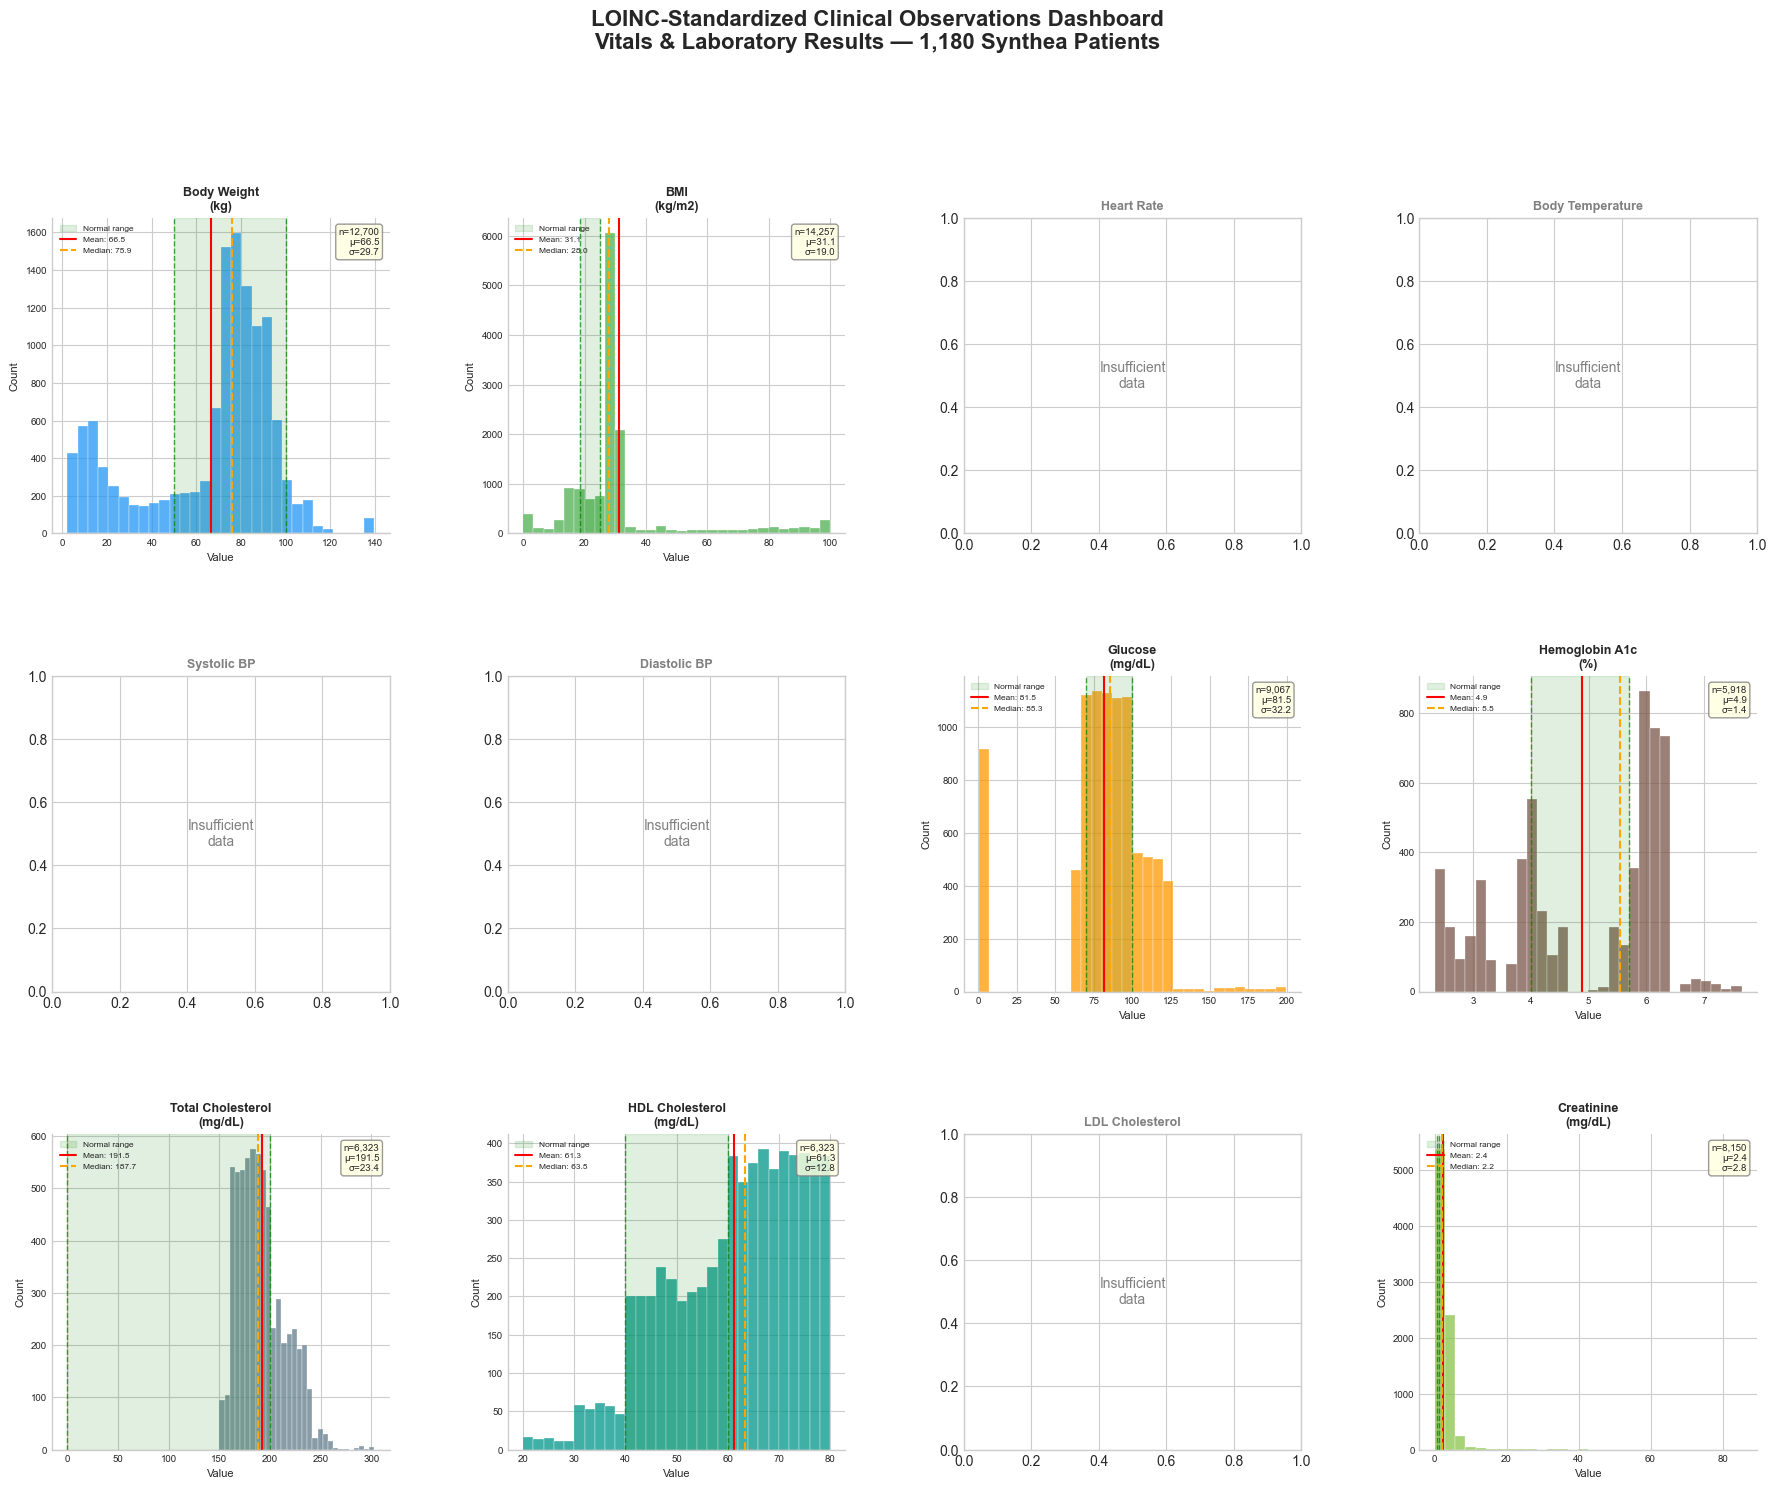

✅ Cell 6 Complete!
📊 Chart saved → output/loinc_vitals_dashboard.png



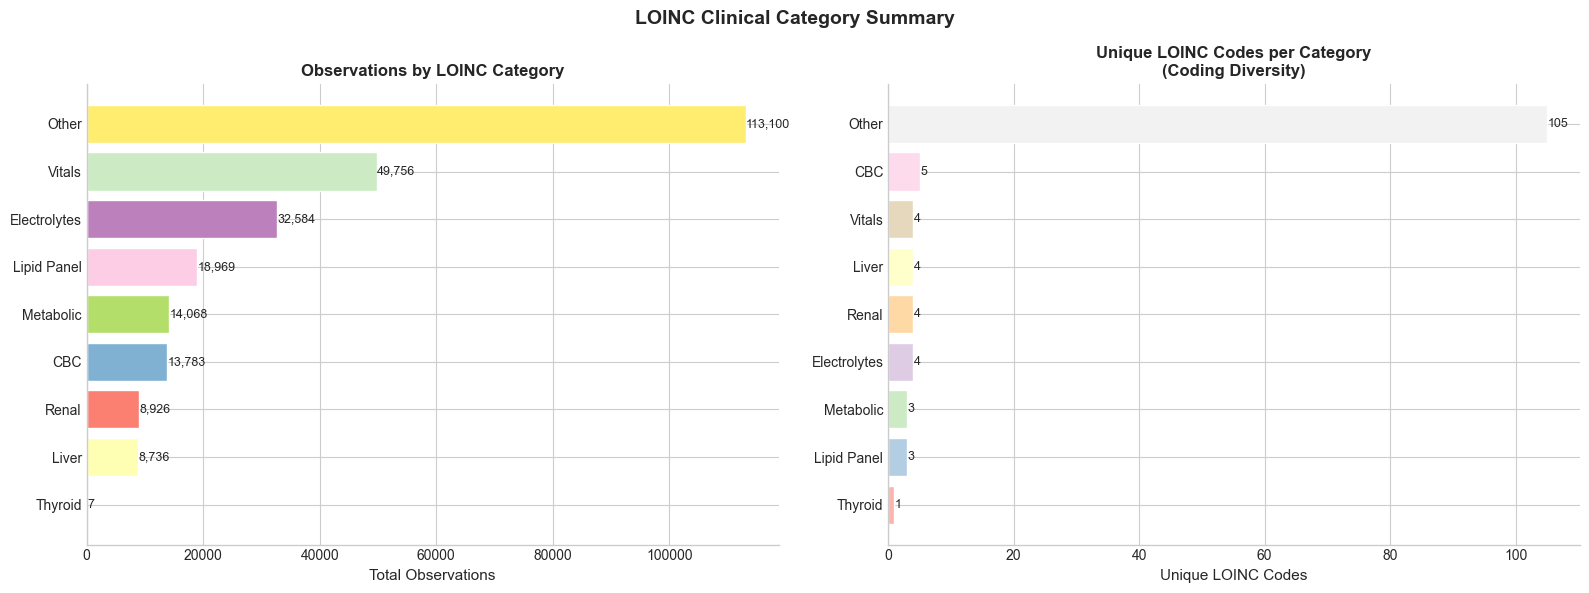

✅ Category Summary saved → output/loinc_category_summary.png

📊 Cell 6 Complete! You now have:
   ✅ output/loinc_vitals_dashboard.png
   ✅ output/loinc_category_summary.png



In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Clinical reference ranges for annotations
CLINICAL_RANGES = {
    'Body Weight':       {'normal': (50, 100),  'unit': 'kg'},
    'BMI':               {'normal': (18.5, 24.9),'unit': 'kg/m2'},
    'Heart Rate':        {'normal': (60, 100),   'unit': '/min'},
    'Body Temperature':  {'normal': (36.1, 37.2),'unit': '°C'},
    'Systolic BP':       {'normal': (90, 120),   'unit': 'mmHg'},
    'Diastolic BP':      {'normal': (60, 80),    'unit': 'mmHg'},
    'Glucose':           {'normal': (70, 100),   'unit': 'mg/dL'},
    'Hemoglobin A1c':    {'normal': (4, 5.7),    'unit': '%'},
    'Total Cholesterol': {'normal': (0, 200),    'unit': 'mg/dL'},
    'HDL Cholesterol':   {'normal': (40, 60),    'unit': 'mg/dL'},
    'LDL Cholesterol':   {'normal': (0, 100),    'unit': 'mg/dL'},
    'Creatinine':        {'normal': (0.6, 1.2),  'unit': 'mg/dL'},
}

def plot_loinc_dashboard(loinc_df: pd.DataFrame):
    """
    Create comprehensive LOINC clinical observations dashboard
    Shows vitals + labs with clinical reference ranges
    """

    fig = plt.figure(figsize=(22, 16))
    fig.suptitle(
        'LOINC-Standardized Clinical Observations Dashboard\n'
        'Vitals & Laboratory Results — 1,180 Synthea Patients',
        fontsize=16, fontweight='bold', y=1.01
    )

    gs = gridspec.GridSpec(3, 4, figure=fig,
                           hspace=0.45, wspace=0.35)

    # Observations to plot — rows x cols
    obs_to_plot = [
        # Row 1 — Vitals
        ('Body Weight',       '#2196F3'),
        ('BMI',               '#4CAF50'),
        ('Heart Rate',        '#FF5722'),
        ('Body Temperature',  '#9C27B0'),
        # Row 2 — BP & Metabolic
        ('Systolic BP',       '#F44336'),
        ('Diastolic BP',      '#E91E63'),
        ('Glucose',           '#FF9800'),
        ('Hemoglobin A1c',    '#795548'),
        # Row 3 — Lipids & Renal
        ('Total Cholesterol', '#607D8B'),
        ('HDL Cholesterol',   '#009688'),
        ('LDL Cholesterol',   '#3F51B5'),
        ('Creatinine',        '#8BC34A'),
    ]

    for idx, (obs_name, color) in enumerate(obs_to_plot):
        row = idx // 4
        col = idx % 4
        ax  = fig.add_subplot(gs[row, col])

        # Filter data for this observation
        subset = loinc_df[
            loinc_df['std_name'].str.contains(
                obs_name, case=False, na=False)
            & loinc_df['value'].notna()
            & (loinc_df['value'] > 0)
        ]['value'].dropna()

        if len(subset) < 5:
            ax.text(0.5, 0.5, f'Insufficient\ndata',
                    ha='center', va='center',
                    transform=ax.transAxes,
                    fontsize=10, color='gray')
            ax.set_title(obs_name, fontsize=9,
                         fontweight='bold', color='gray')
            continue

        # ── Histogram ────────────────────────────────────
        n, bins, patches = ax.hist(
            subset,
            bins=30,
            color=color,
            alpha=0.75,
            edgecolor='white',
            linewidth=0.3
        )

        # ── Clinical reference range shading ─────────────
        if obs_name in CLINICAL_RANGES:
            ref = CLINICAL_RANGES[obs_name]
            lo, hi = ref['normal']
            unit   = ref['unit']
            ax.axvspan(lo, hi, alpha=0.12,
                       color='green', label='Normal range')
            ax.axvline(lo, color='green', linestyle='--',
                       linewidth=1, alpha=0.7)
            ax.axvline(hi, color='green', linestyle='--',
                       linewidth=1, alpha=0.7)
        else:
            unit = ''

        # ── Mean & Median lines ───────────────────────────
        mean_val   = subset.mean()
        median_val = subset.median()
        ax.axvline(mean_val, color='red', linestyle='-',
                   linewidth=1.5, label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='orange',
                   linestyle='--', linewidth=1.5,
                   label=f'Median: {median_val:.1f}')

        # ── Stats annotation box ──────────────────────────
        stats_text = (f'n={len(subset):,}\n'
                      f'μ={mean_val:.1f}\n'
                      f'σ={subset.std():.1f}')
        ax.text(0.97, 0.97, stats_text,
                transform=ax.transAxes,
                fontsize=7, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='lightyellow',
                          edgecolor='gray', alpha=0.8))

        ax.set_title(f'{obs_name}\n({unit})',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Count',  fontsize=8)
        ax.tick_params(labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(fontsize=6, loc='upper left')

    plt.savefig('output/loinc_vitals_dashboard.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Cell 6 Complete!")
    print("📊 Chart saved → output/loinc_vitals_dashboard.png")


def plot_category_summary(loinc_df: pd.DataFrame):
    """
    Summary chart — observations per category
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('LOINC Clinical Category Summary',
                 fontsize=14, fontweight='bold')

    # ── Left: Category counts ─────────────────────────────
    cat_counts = (loinc_df.groupby('category')
                  .size()
                  .sort_values(ascending=True))

    cat_colors = plt.cm.Set3(
        np.linspace(0, 1, len(cat_counts)))
    bars = axes[0].barh(
        cat_counts.index,
        cat_counts.values,
        color=cat_colors,
        edgecolor='white'
    )
    axes[0].set_xlabel('Total Observations', fontsize=11)
    axes[0].set_title('Observations by LOINC Category',
                      fontsize=12, fontweight='bold')
    for bar in bars:
        axes[0].text(
            bar.get_width() + 100,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}',
            va='center', fontsize=9
        )
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # ── Right: Unique codes per category ──────────────────
    unique_codes = (loinc_df.groupby('category')['loinc_code']
                    .nunique()
                    .sort_values(ascending=True))

    bars2 = axes[1].barh(
        unique_codes.index,
        unique_codes.values,
        color=plt.cm.Pastel1(
            np.linspace(0, 1, len(unique_codes))),
        edgecolor='white'
    )
    axes[1].set_xlabel('Unique LOINC Codes', fontsize=11)
    axes[1].set_title('Unique LOINC Codes per Category\n'
                      '(Coding Diversity)',
                      fontsize=12, fontweight='bold')
    for bar in bars2:
        axes[1].text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width())}',
            va='center', fontsize=9
        )
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('output/loinc_category_summary.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Category Summary saved → "
          "output/loinc_category_summary.png")


# ── Run both charts ────────────────────────────────────────
plot_loinc_dashboard(loinc_df)
print()
plot_category_summary(loinc_df)
print()
print("=" * 55)
print("📊 Cell 6 Complete! You now have:")
print("   ✅ output/loinc_vitals_dashboard.png")
print("   ✅ output/loinc_category_summary.png")
print("=" * 55)
print()

# ============================================================
# section 7: RxNorm Medication Code Analysis
# Standard: RxNorm — US standard for medication naming
# Used by: All EHR systems, pharmacies, PBMs, e-prescribing
# FHIR Resource: MedicationRequest
# ============================================================

✅ RxNorm Medication Extraction Complete!
   Total medication records:    14,102
   Unique RxNorm codes:         149
   Unique patients:             1,106
   Classified by drug class:    3,298 (23.4%)

📋 Top 15 Most Prescribed Medications:
────────────────────────────────────────────────────────────
  205923     1 ML Epoetin Alfa 4000 UNT/ML Injection [Epogen] Other                4,133  [Other]
  316672     Simvastatin            Statin               2,306  [Cardiovascular]
  1736854    Cisplatin 50 MG Injection Other                  880  [Other]
  583214     PACLitaxel 100 MG Injection Other                  820  [Other]
  313782     Acetaminophen          Analgesic              622  [Pain]
  562251     Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet Other                  266  [Other]
  849574     Naproxen sodium 220 MG Oral Tablet Other                  264  [Other]
  310965     Ibuprofen              NSAID                  178  [Pain]
  316049     Hydrochlorothiazide 25 MG Oth

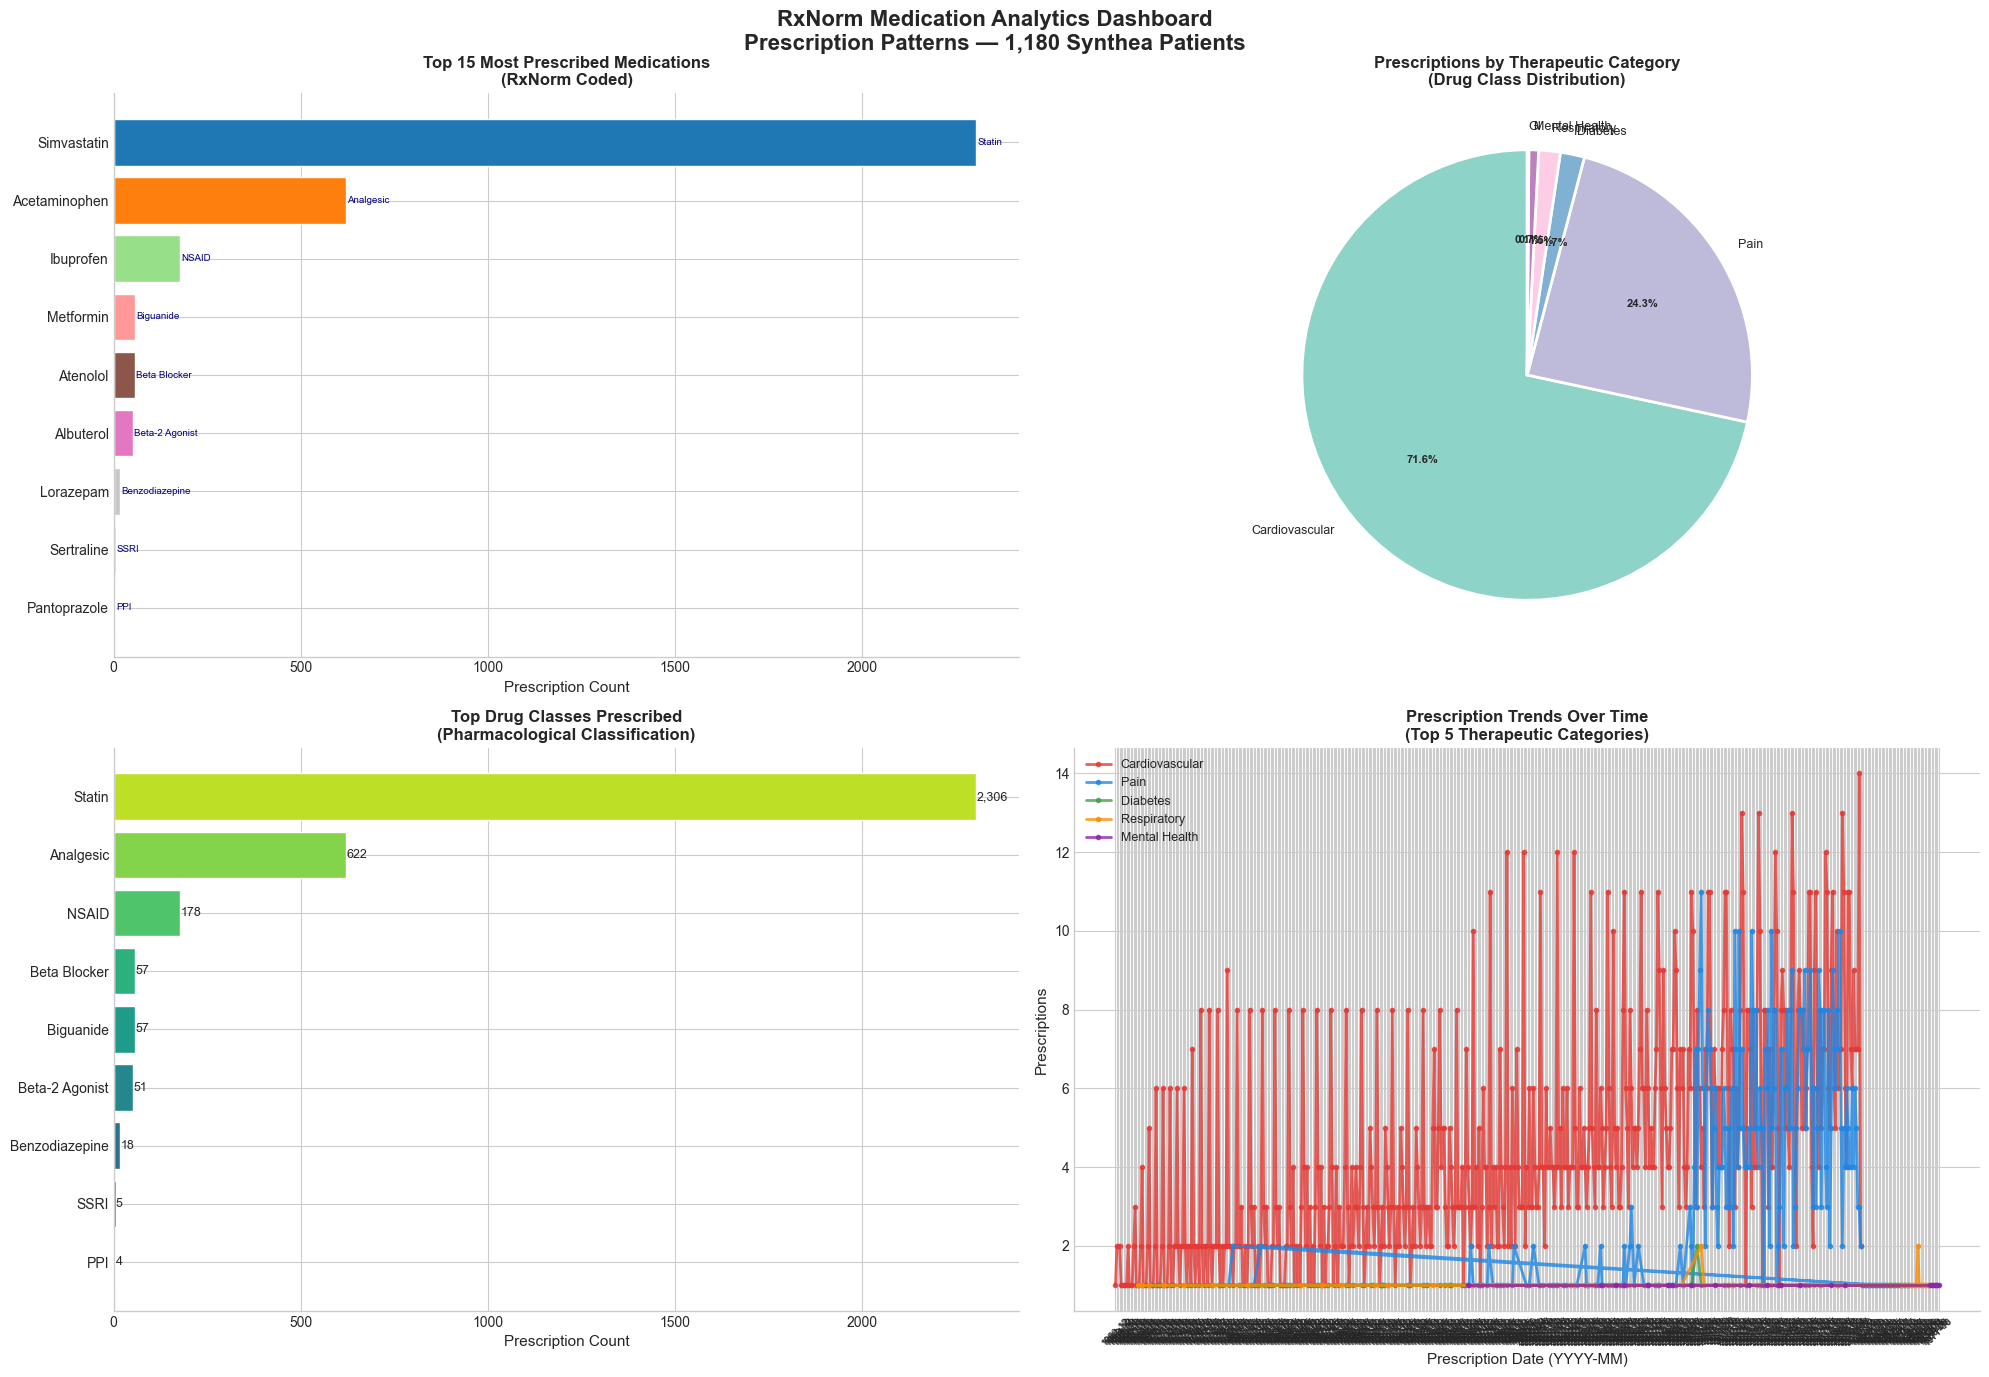

✅ Chart saved → output/rxnorm_medication_dashboard.png

📊 Cell 7 Complete! You now have:
   ✅ output/icd10_disease_burden.png
   ✅ output/loinc_vitals_dashboard.png
   ✅ output/loinc_category_summary.png
   ✅ output/rxnorm_medication_dashboard.png



In [9]:
# RxNorm Drug Class Reference
RXNORM_DRUG_CLASSES = {
    # Cardiovascular
    '316672':  ('Simvastatin',      'Statin',           'Cardiovascular'),
    '617314':  ('Atorvastatin',     'Statin',           'Cardiovascular'),
    '308460':  ('Lisinopril',       'ACE Inhibitor',    'Cardiovascular'),
    '214354':  ('Amlodipine',       'CCB',              'Cardiovascular'),
    '1091643': ('Losartan',         'ARB',              'Cardiovascular'),
    '854925':  ('Metoprolol',       'Beta Blocker',     'Cardiovascular'),
    '197361':  ('Atenolol',         'Beta Blocker',     'Cardiovascular'),
    '310798':  ('Hydrochlorothiazide','Diuretic',       'Cardiovascular'),
    '313988':  ('Furosemide',       'Diuretic',         'Cardiovascular'),
    '308136':  ('Carvedilol',       'Beta Blocker',     'Cardiovascular'),
    # Diabetes
    '860975':  ('Metformin',        'Biguanide',        'Diabetes'),
    '847232':  ('Insulin Glargine', 'Insulin',          'Diabetes'),
    '311036':  ('Glipizide',        'Sulfonylurea',     'Diabetes'),
    '897122':  ('Sitagliptin',      'DPP-4 Inhibitor',  'Diabetes'),
    '2200539': ('Semaglutide',      'GLP-1 Agonist',    'Diabetes'),
    # Mental Health
    '596926':  ('Sertraline',       'SSRI',             'Mental Health'),
    '321988':  ('Fluoxetine',       'SSRI',             'Mental Health'),
    '310384':  ('Escitalopram',     'SSRI',             'Mental Health'),
    '835564':  ('Duloxetine',       'SNRI',             'Mental Health'),
    '41493':   ('Alprazolam',       'Benzodiazepine',   'Mental Health'),
    '308971':  ('Lorazepam',        'Benzodiazepine',   'Mental Health'),
    # Pain & Anti-inflammatory
    '310965':  ('Ibuprofen',        'NSAID',            'Pain'),
    '313782':  ('Acetaminophen',    'Analgesic',        'Pain'),
    '308054':  ('Naproxen',         'NSAID',            'Pain'),
    '310231':  ('Gabapentin',       'Anticonvulsant',   'Pain'),
    '1049502': ('Oxycodone',        'Opioid',           'Pain'),
    # Respiratory
    '745679':  ('Albuterol',        'Beta-2 Agonist',   'Respiratory'),
    '896188':  ('Fluticasone',      'Corticosteroid',   'Respiratory'),
    '310547':  ('Montelukast',      'Leukotriene',      'Respiratory'),
    # Antibiotics
    '723':     ('Amoxicillin',      'Penicillin',       'Antibiotic'),
    '308177':  ('Azithromycin',     'Macrolide',        'Antibiotic'),
    '309110':  ('Ciprofloxacin',    'Fluoroquinolone',  'Antibiotic'),
    # Thyroid
    '310629':  ('Levothyroxine',    'Thyroid Hormone',  'Thyroid'),
    # Bone Health
    '310448':  ('Alendronate',      'Bisphosphonate',   'Bone Health'),
    '343050':  ('Calcium',          'Supplement',       'Bone Health'),
    # GI
    '310527':  ('Omeprazole',       'PPI',              'GI'),
    '311372':  ('Pantoprazole',     'PPI',              'GI'),
    # Blood Thinners
    '308351':  ('Warfarin',         'Anticoagulant',    'Blood Thinner'),
    '1037045': ('Apixaban',         'Anticoagulant',    'Blood Thinner'),
    '1116632': ('Rivaroxaban',      'Anticoagulant',    'Blood Thinner'),
    '309952':  ('Aspirin',          'Antiplatelet',     'Blood Thinner'),
}

def extract_rxnorm_medications(med_requests: list) -> pd.DataFrame:
    """
    Extract RxNorm medication codes from FHIR MedicationRequest
    Demonstrates: Medication data standardization
    Standards: RxNorm, HL7 FHIR R4 MedicationRequest resource
    """
    records = []

    for med in med_requests:
        patient_id = med.get('_patient_id', 'Unknown')
        status     = med.get('status', 'unknown')
        authored   = med.get('authoredOn', '')[:7]

        # FHIR MedicationRequest — medication coding
        med_coding = (med.get('medicationCodeableConcept', {})
                     .get('coding', []))

        for coding in med_coding:
            system  = coding.get('system', '')
            code    = coding.get('code',   '')
            display = coding.get('display','')

            if 'rxnorm' in system.lower():
                # Look up drug class
                if code in RXNORM_DRUG_CLASSES:
                    med_name, drug_class, category = \
                        RXNORM_DRUG_CLASSES[code]
                    classified = True
                else:
                    med_name   = display
                    drug_class = 'Other'
                    category   = 'Other'
                    classified = False

                records.append({
                    'patient_id':  patient_id,
                    'rxnorm_code': code,
                    'display':     display,
                    'med_name':    med_name,
                    'drug_class':  drug_class,
                    'category':    category,
                    'classified':  classified,
                    'status':      status,
                    'date':        authored,
                })

    df = pd.DataFrame(records)

    if df.empty:
        print("❌ No RxNorm medications found!")
        return df

    classified_count = df['classified'].sum()
    pct = classified_count / len(df) * 100

    print("=" * 60)
    print("✅ RxNorm Medication Extraction Complete!")
    print("=" * 60)
    print(f"   Total medication records:    {len(df):,}")
    print(f"   Unique RxNorm codes:         {df['rxnorm_code'].nunique():,}")
    print(f"   Unique patients:             {df['patient_id'].nunique():,}")
    print(f"   Classified by drug class:    "
          f"{classified_count:,} ({pct:.1f}%)")
    print()

    # Top medications
    print("📋 Top 15 Most Prescribed Medications:")
    print("─" * 60)
    top_meds = (df.groupby(['rxnorm_code','med_name',
                            'drug_class','category'])
                .size()
                .reset_index(name='count')
                .sort_values('count', ascending=False)
                .head(15))
    for _, row in top_meds.iterrows():
        print(f"  {row['rxnorm_code']:<10} "
              f"{row['med_name']:<22} "
              f"{row['drug_class']:<20} "
              f"{row['count']:>5,}  "
              f"[{row['category']}]")

    print()

    # Category breakdown
    print("📋 Prescriptions by Therapeutic Category:")
    print("─" * 50)
    cat_counts = (df.groupby('category')
                  .size()
                  .sort_values(ascending=False))
    for cat, count in cat_counts.items():
        bar = '█' * int(count / cat_counts.max() * 25)
        print(f"  {cat:<15} {bar:<25} {count:,}")

    return df


def plot_rxnorm_dashboard(meds_df: pd.DataFrame):
    """
    4-panel RxNorm medication analytics dashboard
    """
    rxnorm_df = meds_df[meds_df['classified'] == True]

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle(
        'RxNorm Medication Analytics Dashboard\n'
        'Prescription Patterns — 1,180 Synthea Patients',
        fontsize=16, fontweight='bold'
    )

    # ── Chart 1: Top 15 Medications (Top Left) ────────────
    ax1 = axes[0, 0]
    top15 = (rxnorm_df.groupby(['med_name', 'drug_class'])
             .size()
             .reset_index(name='count')
             .sort_values('count', ascending=False)
             .head(15))

    colors1 = plt.cm.tab20(np.linspace(0, 1, len(top15)))
    bars1 = ax1.barh(
        top15['med_name'],
        top15['count'],
        color=colors1,
        edgecolor='white'
    )
    ax1.invert_yaxis()
    ax1.set_xlabel('Prescription Count', fontsize=11)
    ax1.set_title('Top 15 Most Prescribed Medications\n(RxNorm Coded)',
                  fontsize=12, fontweight='bold')

    for bar, (_, row) in zip(bars1, top15.iterrows()):
        ax1.text(
            bar.get_width() + 2,
            bar.get_y() + bar.get_height() / 2,
            row['drug_class'],
            va='center', fontsize=7, color='navy'
        )
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ── Chart 2: Therapeutic Category Pie (Top Right) ─────
    ax2 = axes[0, 1]
    cat_counts = (rxnorm_df.groupby('category')
                  .size()
                  .sort_values(ascending=False))

    colors2 = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
    wedges, texts, autotexts = ax2.pie(
        cat_counts.values,
        labels=cat_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors2,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
        textprops={'fontsize': 9}
    )
    for autotext in autotexts:
        autotext.set_fontsize(8)
        autotext.set_fontweight('bold')
    ax2.set_title('Prescriptions by Therapeutic Category\n'
                  '(Drug Class Distribution)',
                  fontsize=12, fontweight='bold')

    # ── Chart 3: Drug Class Breakdown (Bottom Left) ───────
    ax3 = axes[1, 0]
    drug_class_counts = (rxnorm_df.groupby('drug_class')
                         .size()
                         .sort_values(ascending=True)
                         .tail(15))

    colors3 = plt.cm.viridis(
        np.linspace(0.2, 0.9, len(drug_class_counts)))
    bars3 = ax3.barh(
        drug_class_counts.index,
        drug_class_counts.values,
        color=colors3,
        edgecolor='white'
    )
    ax3.set_xlabel('Prescription Count', fontsize=11)
    ax3.set_title('Top Drug Classes Prescribed\n'
                  '(Pharmacological Classification)',
                  fontsize=12, fontweight='bold')
    for bar in bars3:
        ax3.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}',
            va='center', fontsize=9
        )
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    # ── Chart 4: Prescriptions Over Time (Bottom Right) ───
    ax4 = axes[1, 1]
    top5_cats = (rxnorm_df.groupby('category')
                 .size()
                 .sort_values(ascending=False)
                 .head(5).index.tolist())

    trend_colors = ['#E53935','#1E88E5','#43A047',
                    '#FB8C00','#8E24AA']

    for cat, color in zip(top5_cats, trend_colors):
        trend = (rxnorm_df[rxnorm_df['category'] == cat]
                 .groupby('date')
                 .size()
                 .reset_index(name='count'))
        trend = trend[trend['date'] != ''].sort_values('date')

        if len(trend) > 2:
            ax4.plot(
                trend['date'],
                trend['count'],
                marker='o',
                label=cat,
                color=color,
                linewidth=2,
                markersize=3,
                alpha=0.8
            )

    ax4.set_xlabel('Prescription Date (YYYY-MM)', fontsize=11)
    ax4.set_ylabel('Prescriptions', fontsize=11)
    ax4.set_title('Prescription Trends Over Time\n'
                  '(Top 5 Therapeutic Categories)',
                  fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.tick_params(axis='x', rotation=45, labelsize=7)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('output/rxnorm_medication_dashboard.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart saved → output/rxnorm_medication_dashboard.png")


# ── Run it ─────────────────────────────────────────────────
meds_df = extract_rxnorm_medications(
    resources.get('MedicationRequest', []))

print()
plot_rxnorm_dashboard(meds_df)

print()
print("=" * 55)
print("📊 Cell 7 Complete! You now have:")
print("   ✅ output/icd10_disease_burden.png")
print("   ✅ output/loinc_vitals_dashboard.png")
print("   ✅ output/loinc_category_summary.png")
print("   ✅ output/rxnorm_medication_dashboard.png")
print("=" * 55)
print()

# ============================================================
# CELL 8: Healthcare Standards Coverage Summary
# Final summary of all standards demonstrated in this project
# Author: Nipa Shah | github.com/nipa-analytics
# ============================================================

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# quick summary of what we found
print("="*55)
print("Project Summary — Healthcare Standards Analysis")
print("="*55)
print(f"Run date: {datetime.now().strftime('%B %d, %Y')}")
print()

total_resources = sum(len(v) for v in resources.values())

print("Data loaded:")
print(f"  Patients        : {len(resources.get('Patient', [])):,}")
print(f"  Conditions      : {len(resources.get('Condition', [])):,}")
print(f"  Observations    : {len(resources.get('Observation', [])):,}")
print(f"  Medications     : {len(resources.get('MedicationRequest', [])):,}")
print(f"  Encounters      : {len(resources.get('Encounter', [])):,}")
print(f"  Claims          : {len(resources.get('Claim', [])):,}")
print(f"  Total resources : {total_resources:,}")
print()

print("Standards coverage:")
print(f"  SNOMED-CT conditions  : {len(snomed_df):,}")
print(f"  ICD-10 mapped         : {len(icd10_df):,}")
print(f"  LOINC observations    : {len(loinc_df):,}")
print(f"  RxNorm medications    : {len(meds_df):,}")
print()

# top findings
print("Top diagnoses found:")
top3 = (icd10_df.groupby(['icd10_code','icd10_desc'])
        .size().sort_values(ascending=False).head(3))
for (code, desc), count in top3.items():
    print(f"  {code} — {desc}: {count:,}")
print()

print("Top medication categories:")
top_cats = meds_df.groupby('category').size().sort_values(ascending=False).head(3)
for cat, count in top_cats.items():
    print(f"  {cat}: {count:,}")

Project Summary — Healthcare Standards Analysis
Run date: May 03, 2026

Data loaded:
  Patients        : 1,180
  Conditions      : 8,766
  Observations    : 259,929
  Medications     : 14,102
  Encounters      : 46,868
  Claims          : 60,970
  Total resources : 527,113

Standards coverage:
  SNOMED-CT conditions  : 8,766
  ICD-10 mapped         : 4,327
  LOINC observations    : 259,929
  RxNorm medications    : 14,102

Top diagnoses found:
  J09.X9 — Viral Infection: 1,237
  J06.9 — Acute Upper Respiratory Infection: 754
  Z34.90 — Normal Pregnancy: 516

Top medication categories:
  Other: 10,804
  Cardiovascular: 2,363
  Pain: 800


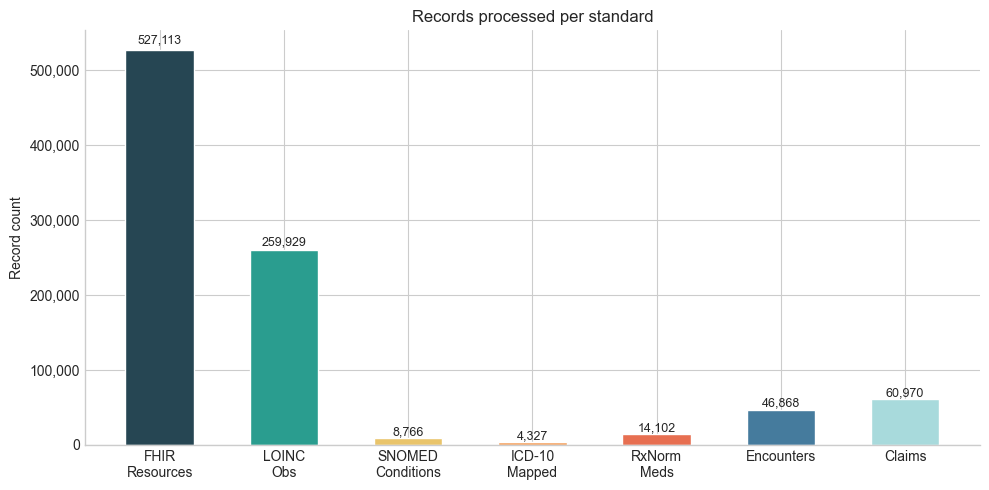

In [11]:
# standards coverage bar chart
fig, ax = plt.subplots(figsize=(10, 5))

labels = ['FHIR\nResources', 'LOINC\nObs', 'SNOMED\nConditions',
          'ICD-10\nMapped', 'RxNorm\nMeds', 'Encounters', 'Claims']

values = [
    total_resources,
    len(loinc_df),
    len(snomed_df),
    len(icd10_df),
    len(meds_df),
    len(resources.get('Encounter', [])),
    len(resources.get('Claim', []))
]

colors = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51','#457b9d','#a8dadc']

bars = ax.bar(labels, values, color=colors, width=0.55, edgecolor='white')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + h*0.01,
            f'{int(h):,}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Record count')
ax.set_title('Records processed per standard')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/standards_summary.png', dpi=150)
plt.show()

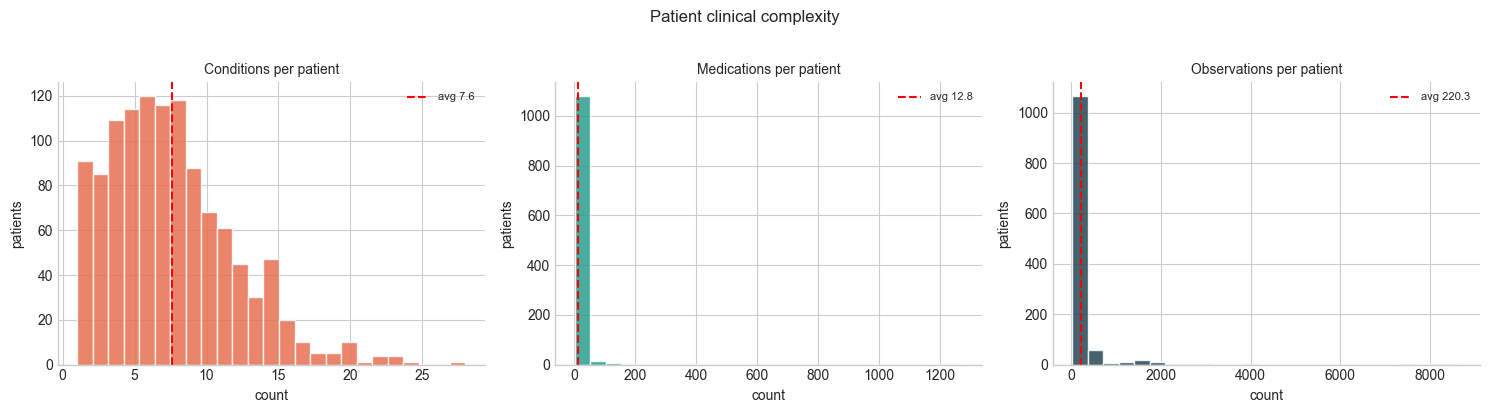

In [12]:
# how complex are patients — conditions, meds, observations per person
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cond_counts = snomed_df.groupby('patient_id').size()
med_counts  = meds_df.groupby('patient_id').size()
obs_counts  = loinc_df.groupby('patient_id').size()

datasets = [
    (cond_counts, 'Conditions per patient', '#e76f51'),
    (med_counts,  'Medications per patient', '#2a9d8f'),
    (obs_counts,  'Observations per patient', '#264653'),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data, bins=25, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'avg {data.mean():.1f}')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('count')
    ax.set_ylabel('patients')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Patient clinical complexity', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('output/patient_complexity.png', dpi=150)
plt.show()

In [13]:
# done — list output files
import os

print("output files saved:")
for f in sorted(os.listdir('output')):
    size = os.path.getsize(f'output/{f}') / 1024
    print(f"  {f}  ({size:.0f} KB)")

output files saved:
  icd10_disease_burden.png  (539 KB)
  loinc_category_summary.png  (83 KB)
  loinc_vitals_dashboard.png  (261 KB)
  patient_complexity.png  (52 KB)
  rxnorm_medication_dashboard.png  (497 KB)
  standards_summary.png  (49 KB)
